In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Read csv file

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/carwale_final.csv")
df.head()

,Car Name,Brand,Price,Fuel Type,Transmission,Engine (cc),Mileage,Seating Capacity,User Rating,URL
0,Aston Martin DB11,Aston Martin,31121622.0,Unknown,Automatic,5198.0,8.9,4.0,4.5,https://www.carwale.com/aston-martin-cars/db11/
1,Aston Martin DB12,Aston Martin,43418919.0,Unknown,Automatic,5198.0,12.75,4.0,4.1,https://www.carwale.com/aston-martin-cars/db12/
2,Aston Martin DBX,Aston Martin,38200000.0,Unknown,Automatic,3982.0,10.1,5.0,4.7,https://www.carwale.com/aston-martin-cars/dbx/
3,Aston Martin Vanquish,Aston Martin,83716216.0,Unknown,Automatic,5203.0,Unknown,2.0,4.9,https://www.carwale.com/aston-martin-cars/vanq...
4,Aston Martin Vantage,Aston Martin,37743243.0,Unknown,Automatic,3982.0,Unknown,2.0,5.0,https://www.carwale.com/aston-martin-cars/vant...


In [3]:
#Shape of the dataset

df.shape

(514, 10)

In [4]:
# Columns of the data set

df.columns

Index(['Car Name', 'Brand', 'Price', 'Fuel Type', 'Transmission',
       'Engine (cc)', 'Mileage', 'Seating Capacity', 'User Rating', 'URL'],
      dtype='object')

In [5]:
# Info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Car Name          514 non-null    object 
 1   Brand             514 non-null    object 
 2   Price             514 non-null    float64
 3   Fuel Type         514 non-null    object 
 4   Transmission      514 non-null    object 
 5   Engine (cc)       514 non-null    object 
 6   Mileage           514 non-null    object 
 7   Seating Capacity  514 non-null    object 
 8   User Rating       514 non-null    object 
 9   URL               514 non-null    object 
dtypes: float64(1), object(9)
memory usage: 40.3+ KB


In [6]:
# Size of the dataset

df.size

5140

In [7]:
# check null values

df.isnull().sum()

,0
Car Name,0
Brand,0
Price,0
Fuel Type,0
Transmission,0
Engine (cc),0
Mileage,0
Seating Capacity,0
User Rating,0
URL,0


In [8]:
# Check Duplicates

df.duplicated().sum()

np.int64(0)

In [9]:
# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [10]:
df["Brand"].value_counts()

,count
Brand,
Mercedes-Benz,51
Mahindra,43
Maruti Suzuki,40
Hyundai,36
Toyota,35
Tata,32
BMW,32
Audi,25
Honda,20


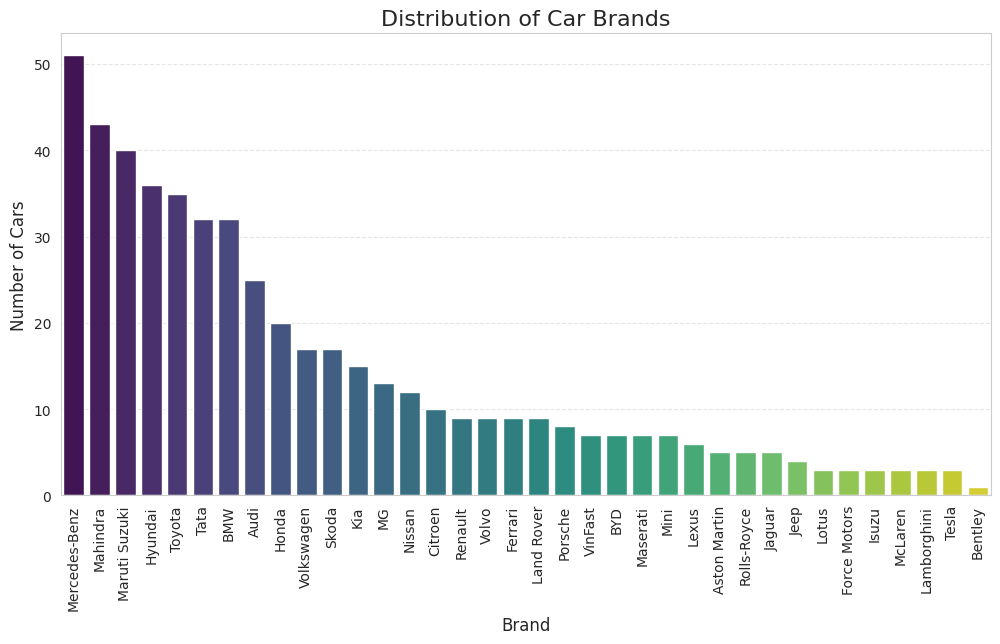

In [11]:
# Univariate analysis
#Brand Distribution

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="Brand",
    order=df["Brand"].value_counts().index,
    palette="viridis"
)

plt.title("Distribution of Car Brands", fontsize=16)
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Number of Cars", fontsize=12)

plt.xticks(rotation=90)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [12]:
df["Fuel Type"].value_counts()

,count
Fuel Type,
Petrol,245
Unknown,218
Diesel,22
Electric,19
CNG,9
Hybrid,1


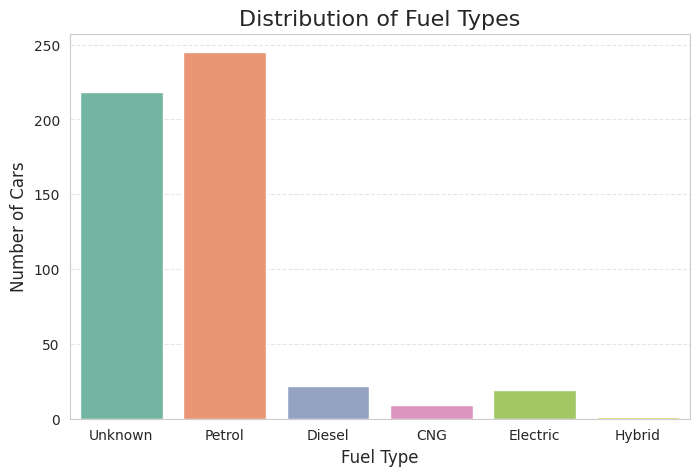

In [13]:
#Fuel Type Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Fuel Type",
    palette="Set2"
)

plt.title("Distribution of Fuel Types", fontsize=16)
plt.xlabel("Fuel Type", fontsize=12)
plt.ylabel("Number of Cars", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


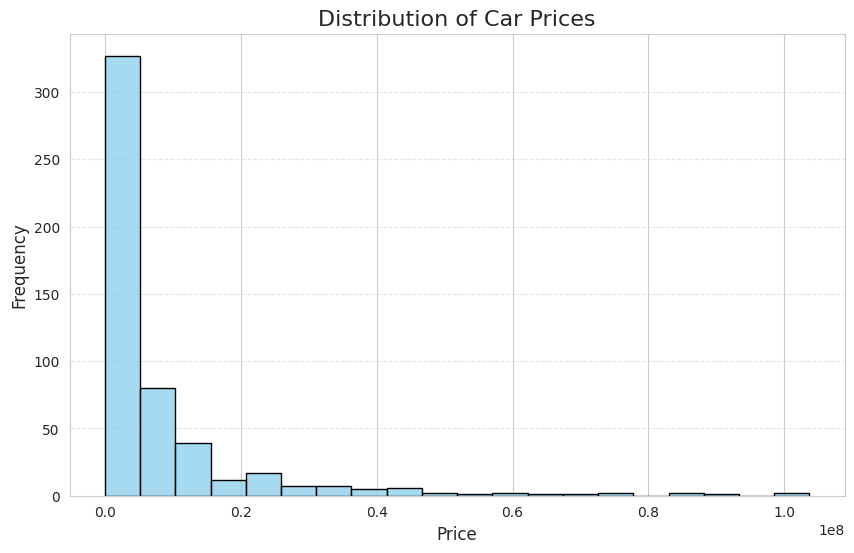

In [14]:
# Price Distribution

df["Price"].describe()

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Price",
    bins=20,
    color="skyblue",
    edgecolor="black"
)

plt.title("Distribution of Car Prices", fontsize=16)
plt.xlabel("Price", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

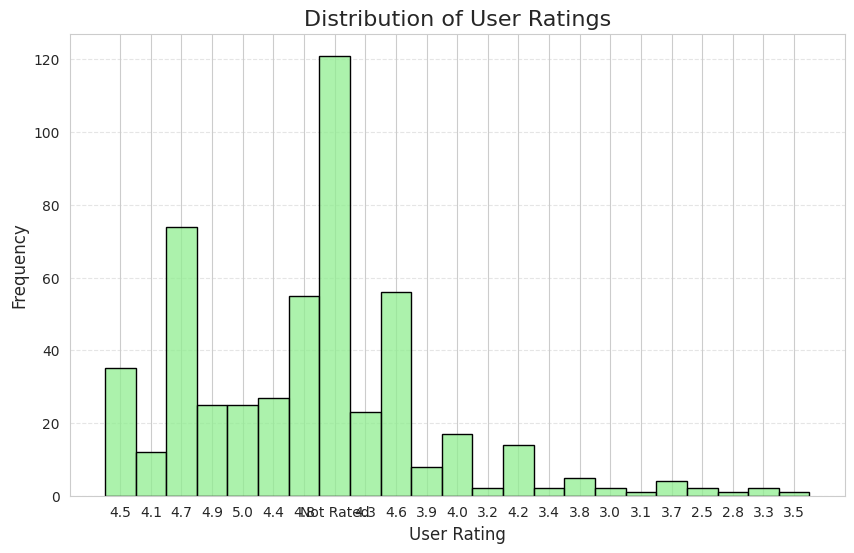

In [15]:
# User Rating Distribution
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="User Rating",
    bins=10,
    color="lightgreen",
    edgecolor="black"
)

plt.title("Distribution of User Ratings", fontsize=16)
plt.xlabel("User Rating", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [16]:
df["User Rating"].dtype

dtype('O')

In [17]:
df["User Rating"].unique()

array(['4.5', '4.1', '4.7', '4.9', '5.0', '4.4', '4.8', 'Not Rated',
       '4.3', '4.6', '3.9', '4.0', '3.2', '4.2', '3.4', '3.8', '3.0',
       '3.1', '3.7', '2.5', '2.8', '3.3', '3.5'], dtype=object)

In [18]:
df["User Rating"] = pd.to_numeric(df["User Rating"], errors="coerce")

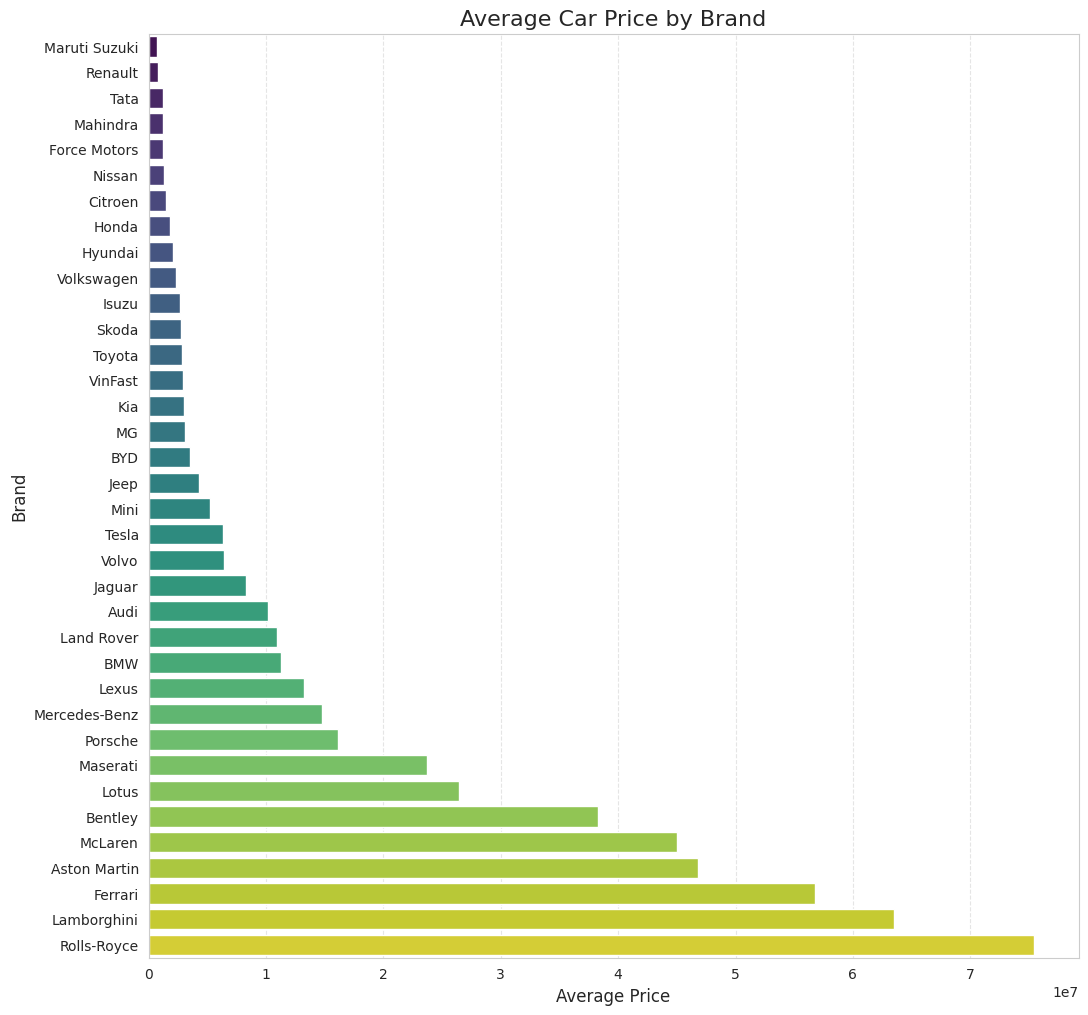

In [19]:
# Bivariate Analysis
# Brand vs Average Price

plt.figure(figsize=(12,12))

avg_price = df.groupby("Brand")["Price"].mean().sort_values()

sns.barplot(
    x=avg_price.values,
    y=avg_price.index,
    palette="viridis"
)

plt.title("Average Car Price by Brand", fontsize=16)
plt.xlabel("Average Price", fontsize=12)
plt.ylabel("Brand", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

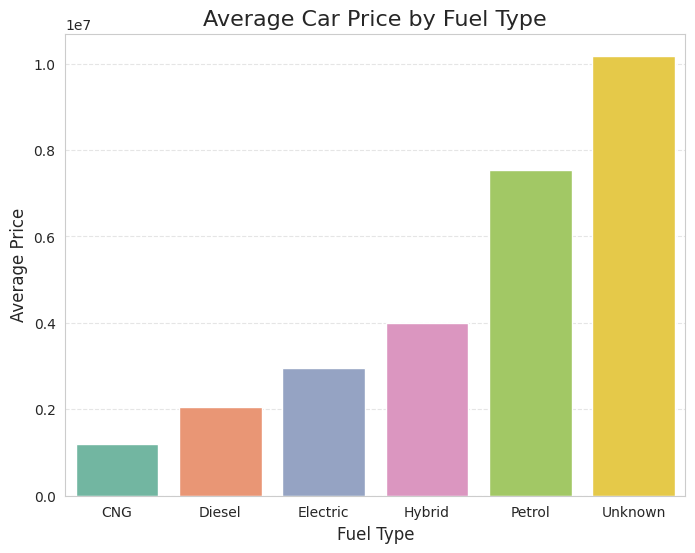

In [20]:
# Fuel Type vs Average Price
plt.figure(figsize=(8,6))

avg_fuel_price = df.groupby("Fuel Type")["Price"].mean().sort_values()

sns.barplot(
    x=avg_fuel_price.index,
    y=avg_fuel_price.values,
    palette="Set2"
)

plt.title("Average Car Price by Fuel Type", fontsize=16)
plt.xlabel("Fuel Type", fontsize=12)
plt.ylabel("Average Price", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

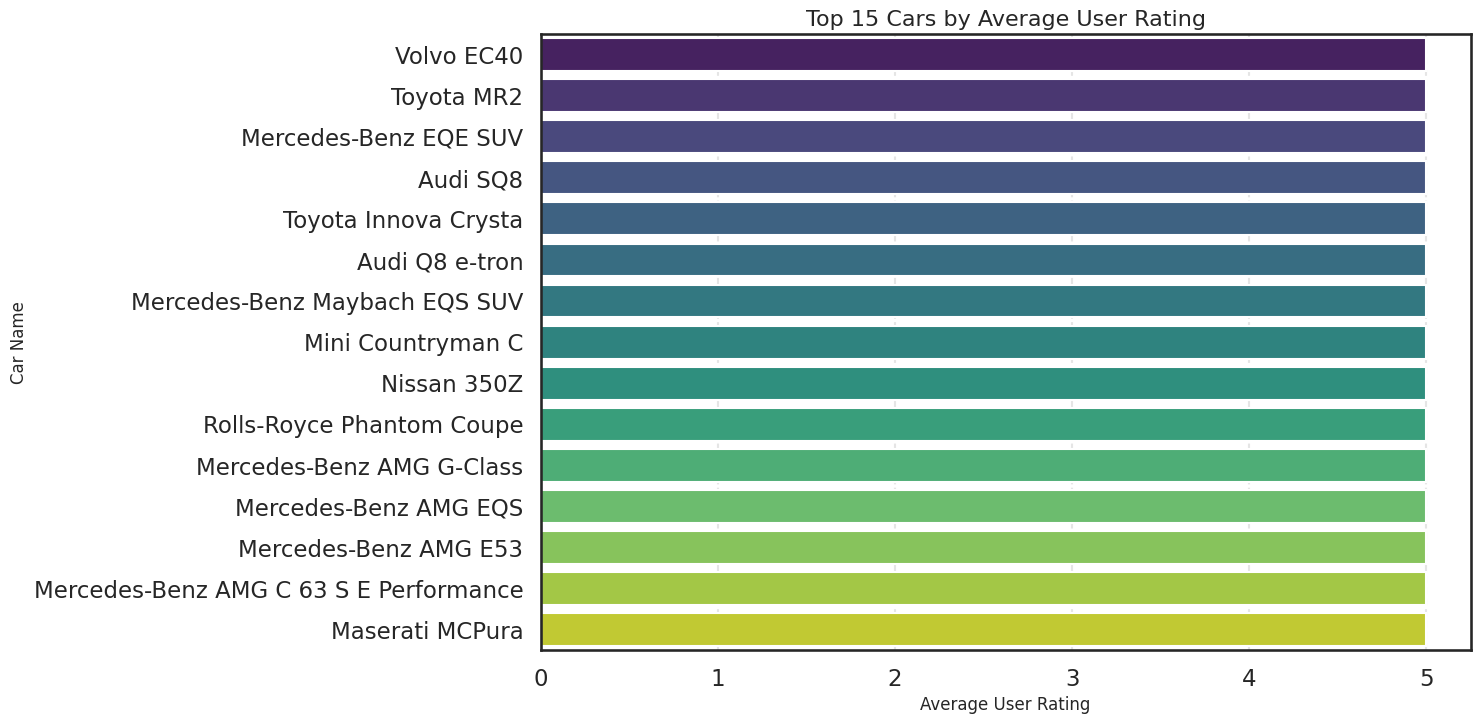

In [36]:
# car vs avg user rating

plt.figure(figsize=(12,8))

top_rated = (
    df.groupby("Car Name")["User Rating"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

sns.barplot(
    x=top_rated.values,
    y=top_rated.index,
    palette="viridis"
)

plt.title("Top 15 Cars by Average User Rating", fontsize=16)
plt.xlabel("Average User Rating", fontsize=12)
plt.ylabel("Car Name", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

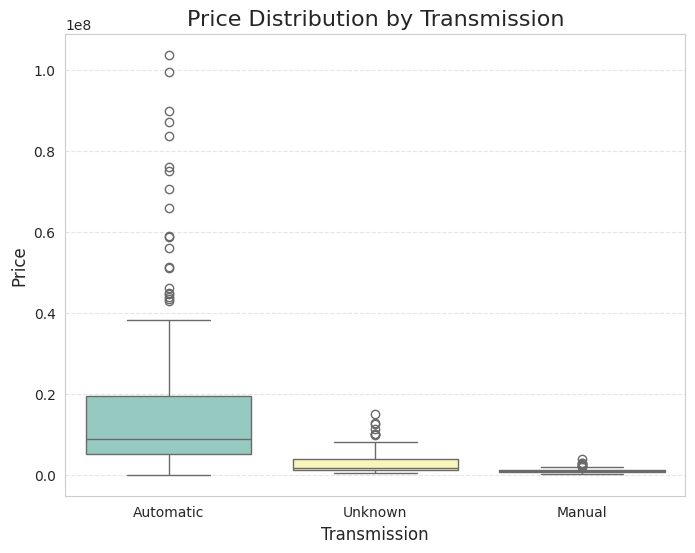

In [22]:
# Transmission vs Average Price

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Transmission",
    y="Price",
    palette="Set3"
)

plt.title("Price Distribution by Transmission", fontsize=16)
plt.xlabel("Transmission", fontsize=12)
plt.ylabel("Price", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [23]:
df["Mileage"].dtype

dtype('O')

In [24]:
df["Mileage"].unique()

array(['8.9', '12.75', '10.1', 'Unknown', '17.4', '14.0', '14.93', '13.4',
       '9.0', '10.8', '10.6', '7.6', '16.35', '11.5', '15.7', '12.61',
       '13.02', '10.0', '10.24', '10.4', '12.0', '7.89', '11.29', '61.9',
       '17.6', '18.64', '18.3', '17.5', '8.0', '7.7', '8.8', '14.4',
       '14.5', '18.65', '17.77', '15.31', '19.7', '15.4', '18.92', '0.0',
       '15.5', '18.74', '17.9', '12.9', '10.87', '15.95', '15.0', '14.85',
       '7.0', '6.9', '17.8', '17.0', '16.0', '15.25', '16.5', '12.4',
       '14.25', '18.06', '24.39', '22.35', '19.19', '25.17', '24.77',
       '19.71', '20.3', '20.01', '20.16', '23.24', '16.39', '24.44',
       '24.8', '20.45', '23.56', '20.27', '9.43', '8.6', '8.2', '10.5',
       '6.5', '14.65', '11.0', '16.82', '15.92', '19.3', '13.7', '17.75',
       '18.0', '6.6', '7.1', '14.86', '18.72', '19.05', '18.73', '18.75',
       '17.69', '16.8', '19.0', '15.3', '19.2', '25.49', '14.2', '10.3',
       '22.3', '11.25', '20.12', '16.13', '19.86', '19.28', 

In [25]:
df["Mileage"] = pd.to_numeric(df["Mileage"], errors="coerce")

In [26]:
df["Mileage"].dtype

dtype('float64')

In [27]:
df["Engine (cc)"].dtype

dtype('O')

In [28]:
df["Engine (cc)"] = pd.to_numeric(df["Engine (cc)"], errors="coerce")

In [29]:
df["Engine (cc)"].dtype

dtype('float64')

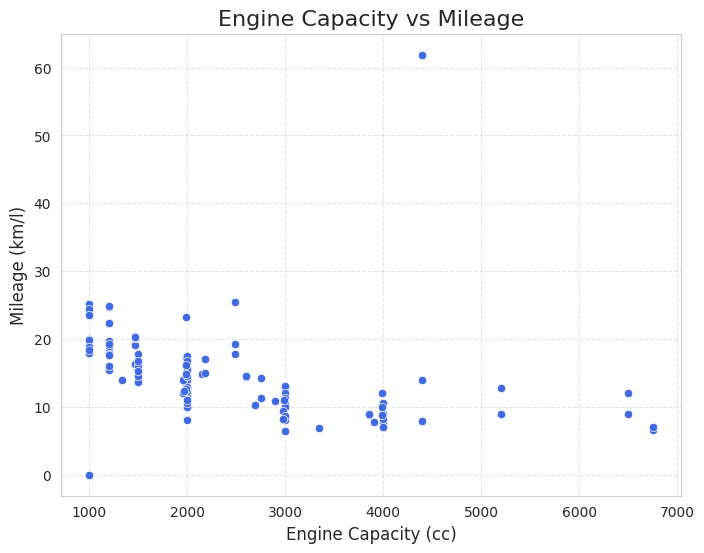

In [30]:
# Engine Capacity vs Mileage

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Engine (cc)",
    y="Mileage",
    color="royalblue"
)

plt.title("Engine Capacity vs Mileage", fontsize=16)
plt.xlabel("Engine Capacity (cc)", fontsize=12)
plt.ylabel("Mileage (km/l)", fontsize=12)

plt.grid(linestyle="--", alpha=0.5)

plt.show()

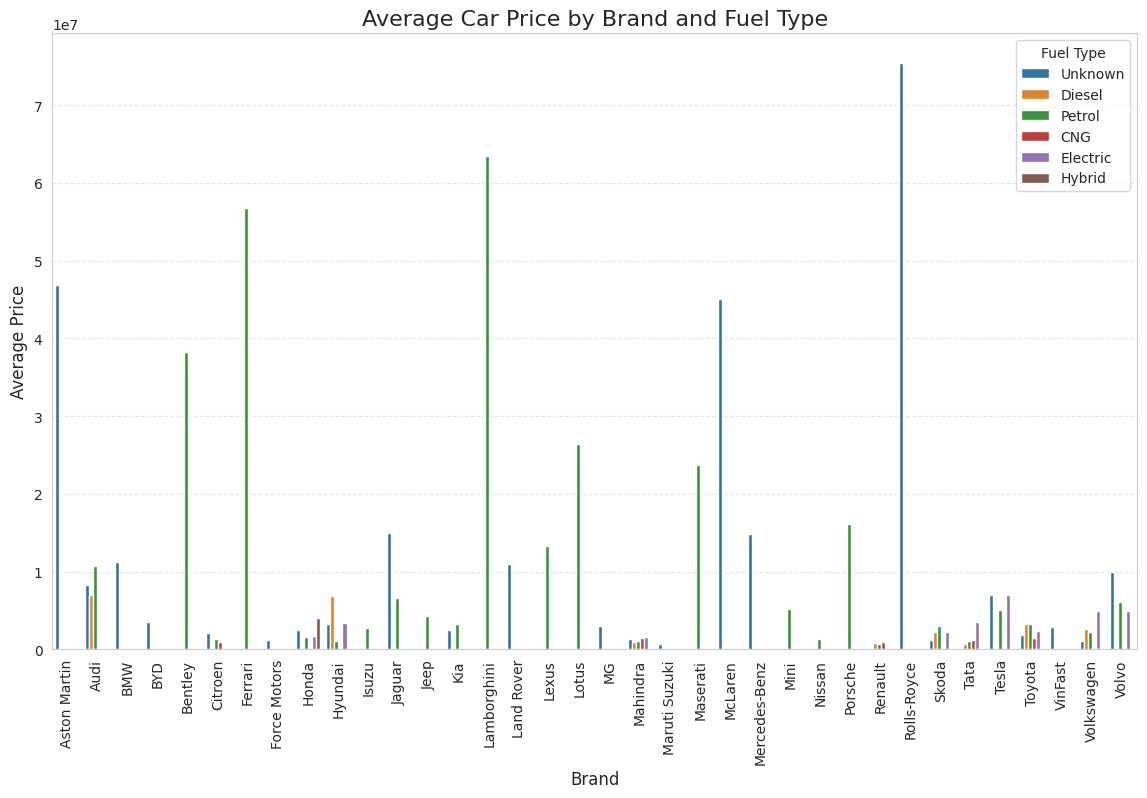

In [31]:
# Multivariate Analysis

# Brand vs Price by Fuel Type

plt.figure(figsize=(14,8))

avg_data = df.groupby(["Brand", "Fuel Type"])["Price"].mean().reset_index()

sns.barplot(
    data=avg_data,
    x="Brand",
    y="Price",
    hue="Fuel Type"
)

plt.title("Average Car Price by Brand and Fuel Type", fontsize=16)
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Average Price", fontsize=12)

plt.xticks(rotation=90)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.legend(title="Fuel Type")

plt.show()

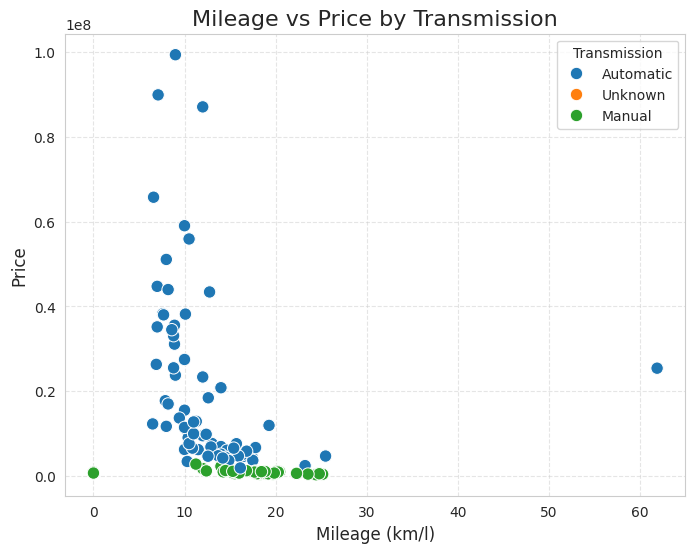

In [32]:
# Mileage vs Price by Transmission

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Mileage",
    y="Price",
    hue="Transmission",
    s=80
)

plt.title("Mileage vs Price by Transmission", fontsize=16)
plt.xlabel("Mileage (km/l)", fontsize=12)
plt.ylabel("Price", fontsize=12)

plt.grid(linestyle="--", alpha=0.5)

plt.legend(title="Transmission")

plt.show()

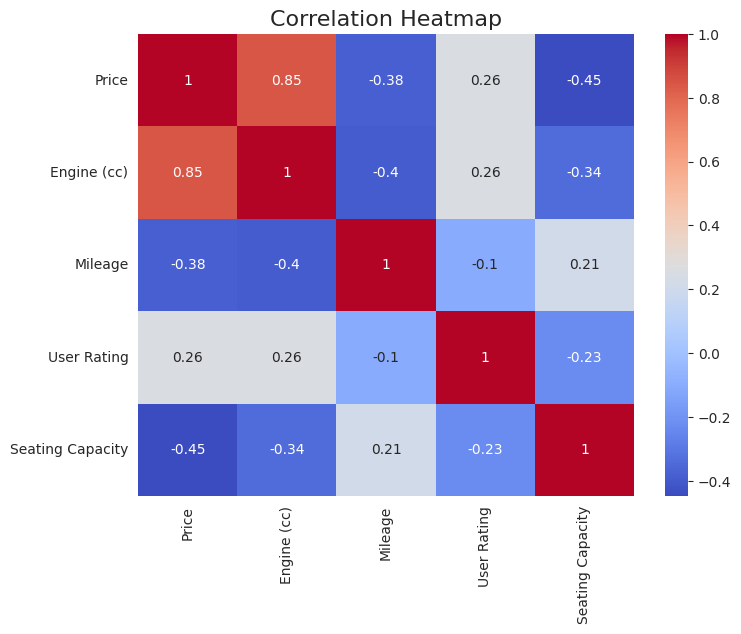

In [33]:
df["Seating Capacity"] = pd.to_numeric(df["Seating Capacity"], errors="coerce")
# Correlation Heatmap
plt.figure(figsize=(8,6))

corr = df[["Price", "Engine (cc)", "Mileage", "User Rating", "Seating Capacity"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap", fontsize=16)

plt.show()

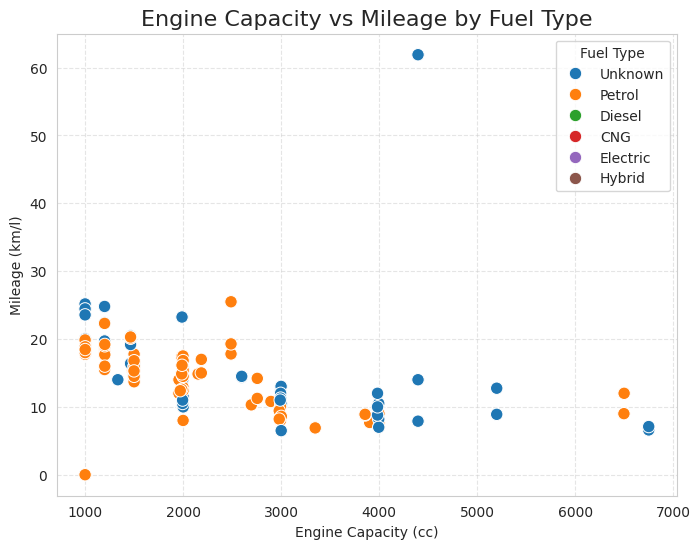

In [34]:
# Engine Capacity vs Price
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Engine (cc)",
    y="Mileage",
    hue="Fuel Type",
    s=80
)

plt.title("Engine Capacity vs Mileage by Fuel Type", fontsize=16)
plt.xlabel("Engine Capacity (cc)")
plt.ylabel("Mileage (km/l)")

plt.grid(linestyle="--", alpha=0.5)

plt.show()

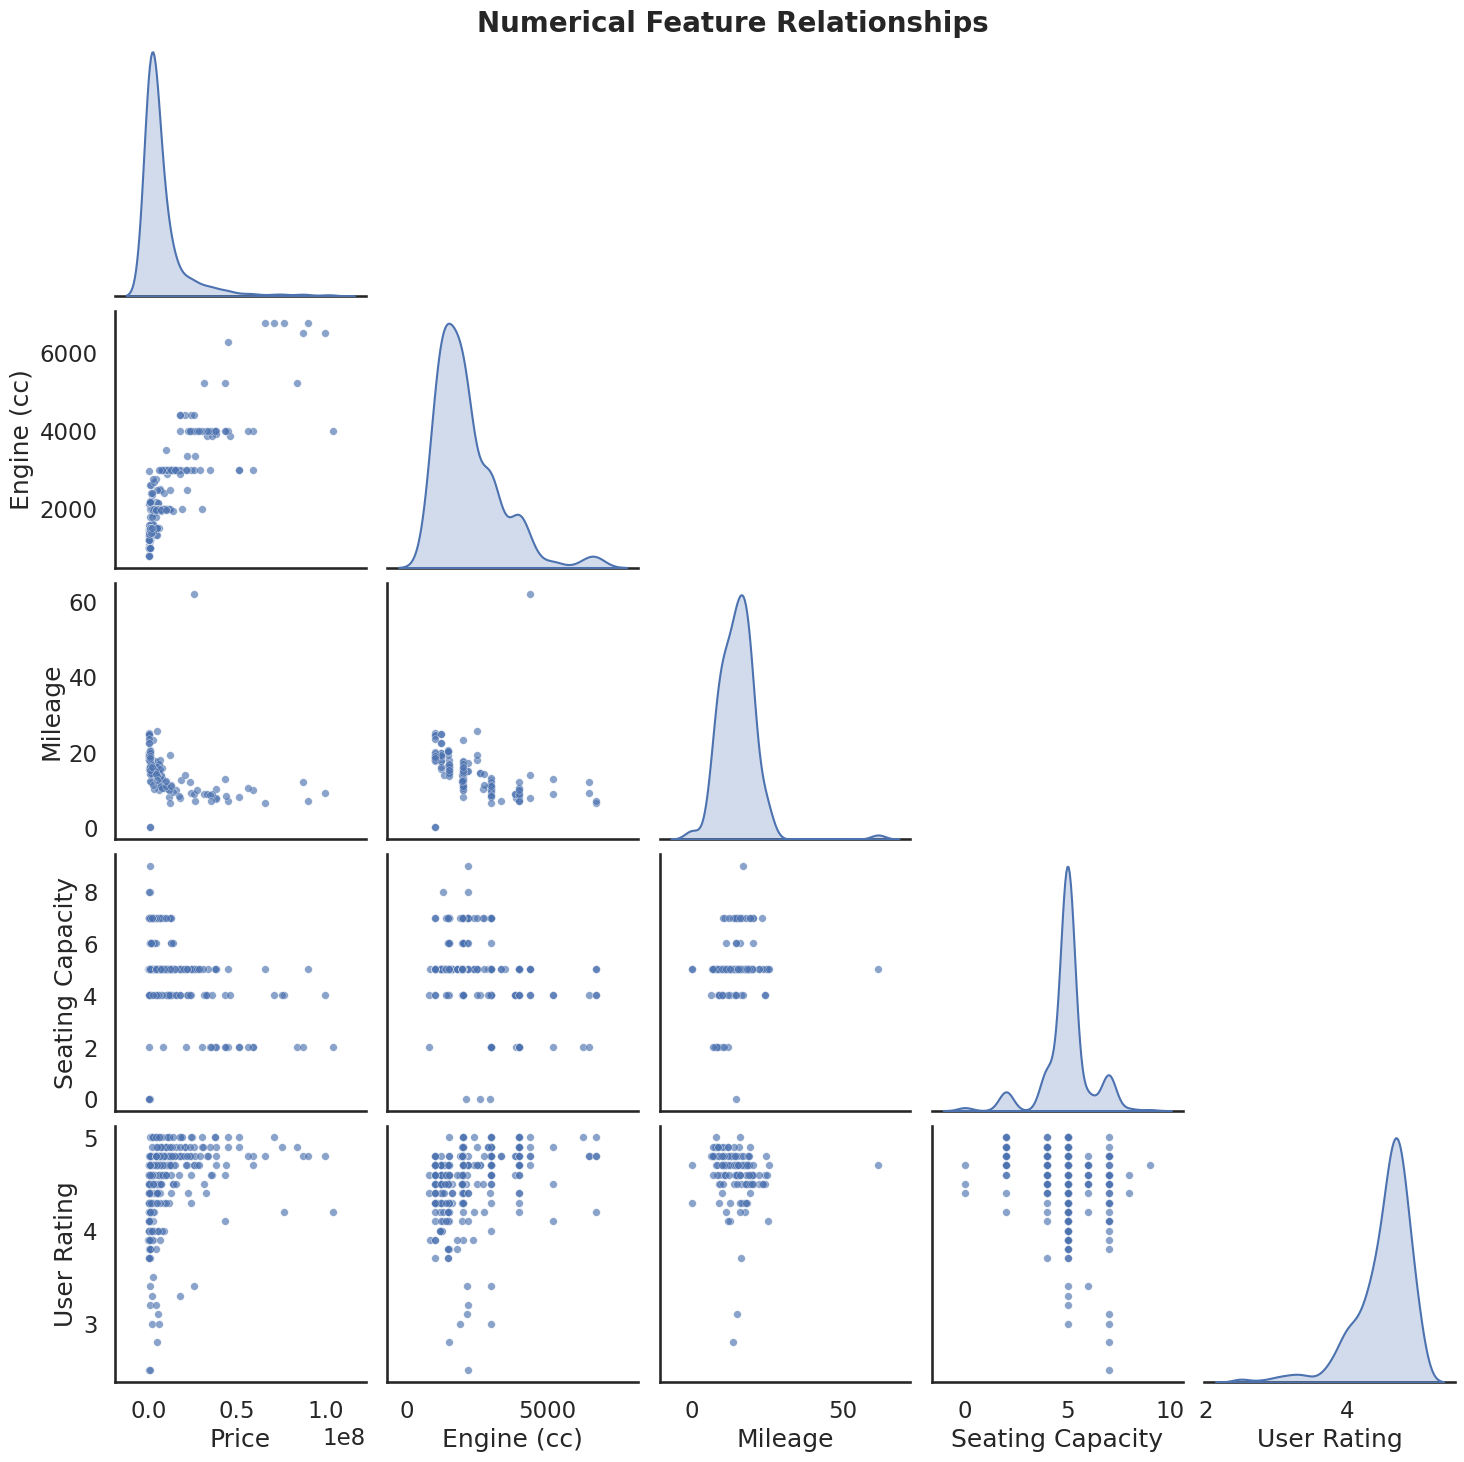

In [35]:
sns.set_theme(
    style="white",
    context="talk",
    font_scale=1.0
)

pair = sns.pairplot(
    df.select_dtypes(include="number"),
    corner=True,
    diag_kind="kde",
    height=3,
    aspect=1,
    plot_kws={
        "s": 30,
        "alpha": 0.65,
        "linewidth": 0.3
    },
    diag_kws={
        "fill": True
    }
)

pair.fig.subplots_adjust(top=0.96)
pair.fig.suptitle(
    "Numerical Feature Relationships",
    fontsize=20,
    fontweight="bold"
)

plt.show()